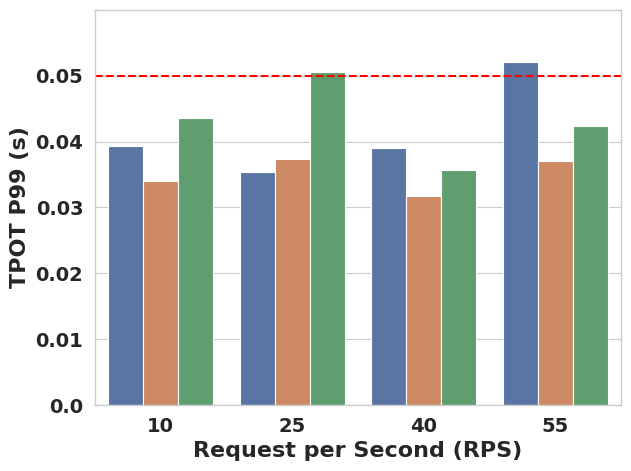

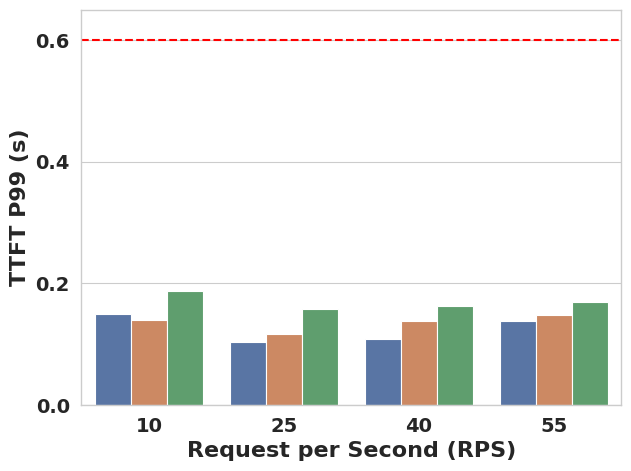

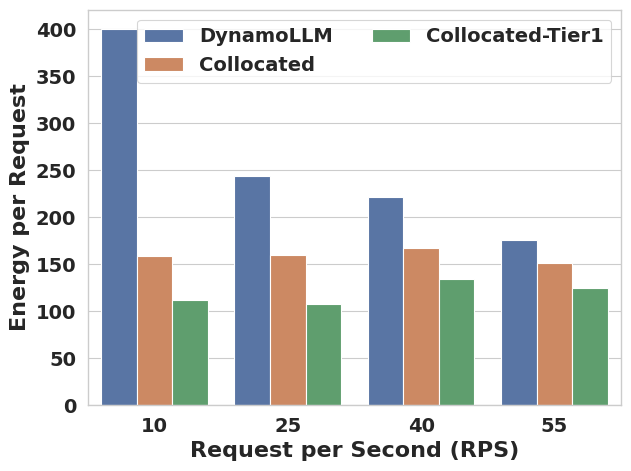

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


path_disag = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug17/disag/metrics.csv"
df_results_disag = pd.read_csv(path_disag)

path_coll = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug18/chunked/metrics.csv"
df_results_coll = pd.read_csv(path_coll)

df_results = pd.concat([df_results_disag, df_results_coll], ignore_index=True)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DYNAMO_AUG16_AZURE_SHAREGPT_MS_1_DVFS': 'DynamoLLM 10',
    'DYNAMO_AUG16_AZURE_SHAREGPT_MS_2_DVFS': 'DynamoLLM 25',
    'DYNAMO_AUG16_AZURE_SHAREGPT_MS_3_DVFS': 'DynamoLLM 40',
    'DYNAMO_AUG16_AZURE_SHAREGPT_MS_4_DVFS': 'DynamoLLM 55',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_1_DVFS': 'Collocated 55',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_2_DVFS': 'Collocated 40',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_3_DVFS': 'Collocated 25',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_4_DVFS': 'Collocated 10',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_1': 'Collocated-Tier1 55',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_2': 'Collocated-Tier1 40',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_3': 'Collocated-Tier1 25',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_4': 'Collocated-Tier1 10',
}

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results["expr_dir"].isin(rename_mapping.values())]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)

# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['DynamoLLM', 'Collocated', 'Collocated-Tier1'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

#################### TPOT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.06)
ax.set_xticks([0, 1, 2, 3, ])
# ax.set_xlim([0.5, 4.5])
ax.set_xticklabels(['10', '25', '40', '55',], fontsize=14, fontweight='bold')
ax.set_yticks([0.0, 0.01, 0.02, 0.03, 0.04, 0.05])
ax.set_yticklabels(['0.0', '0.01', '0.02', '0.03', '0.04', '0.05'], fontsize=14, fontweight='bold')
ax.legend_.remove()

plt.tight_layout()
plt.savefig("figs/dynamo_MS_trace_tpot.pdf", format="pdf")

#################### TTFT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.65)
ax.set_xticks([0, 1, 2, 3, ])
# ax.set_xlim([0.5, 4.5])
ax.set_xticklabels(['10', '25', '40', '55',], fontsize=14, fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend_.remove()

plt.tight_layout()
plt.savefig("figs/dynamo_MS_trace_ttft.pdf", format="pdf")

#################### Energy per request ####################

df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request', fontsize=16, fontweight='bold')
# ax.set_ylim(0, 220)
ax.set_xticks([0, 1, 2, 3, ])
# ax.set_xlim([0.5, 4.5])
ax.set_xticklabels(['10', '25', '40', '55',], fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.set_title('')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
plt.tight_layout()
plt.savefig("figs/dynamo_MS_trace_energy_per_request.pdf", format="pdf")

In [14]:
df_results = df_results[df_results["name"].isin(['DynamoLLM', 'Collocated', 'Collocated-Tier1'])].copy()


# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'DynamoLLM')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results[['expr_dir', 'energy_per_token', 'energy_norm_D']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_token,energy_norm_D
371,DynamoLLM 55,7.165685,0.000000
366,DynamoLLM 40,9.037190,0.000000
361,DynamoLLM 25,9.939287,0.000000
358,DynamoLLM 10,16.096219,0.000000
406,Collocated-Tier1 55,0.632228,91.177006
416,Collocated-Tier1 40,0.690805,92.355974
426,Collocated-Tier1 25,0.548595,94.480544
436,Collocated-Tier1 10,0.574514,96.430749
411,Collocated 55,0.766470,89.303601
421,Collocated 40,0.855715,90.531182
